In [16]:
from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .master("local") \
    .appName("Exercise1") \
    .getOrCreate()

In [17]:
pwd

'/home/jovyan'

In [18]:
df = spark.read.csv("exampleData.csv", header=True, inferSchema=True)
df.show(vertical=True)

-RECORD 0--------------------------------
 _c0                 | 14                
 dateTime            | 01-jan-1990 00:00 
 indicator_rain      | 0                 
 precipitation       | 0.3               
 indicator_temp      | 0                 
 air_temperature     | 9.1               
 indicator_wetb      | 0                 
 wetb                | 9.0               
 dewpt               | 8.9               
 vappr               | 11.4              
 relative_humidity   | 99                
 msl                 | 1006.7            
 indicator_wdsp      | 2                 
 wind_speed          | 7                 
 indicator_wddir     | 2                 
 wind_from_direction | 190               
-RECORD 1--------------------------------
 _c0                 | 15                
 dateTime            | 01-jan-1990 01:00 
 indicator_rain      | 0                 
 precipitation       | 0.2               
 indicator_temp      | 0                 
 air_temperature     | 8.2        

In [19]:
df.printSchema()

root
 |-- _c0: integer (nullable = true)
 |-- dateTime: string (nullable = true)
 |-- indicator_rain: integer (nullable = true)
 |-- precipitation: string (nullable = true)
 |-- indicator_temp: integer (nullable = true)
 |-- air_temperature: string (nullable = true)
 |-- indicator_wetb: integer (nullable = true)
 |-- wetb: string (nullable = true)
 |-- dewpt: string (nullable = true)
 |-- vappr: string (nullable = true)
 |-- relative_humidity: string (nullable = true)
 |-- msl: string (nullable = true)
 |-- indicator_wdsp: integer (nullable = true)
 |-- wind_speed: string (nullable = true)
 |-- indicator_wddir: integer (nullable = true)
 |-- wind_from_direction: integer (nullable = true)



In [11]:
import requests
from pyspark.sql import SparkSession
from pyspark.sql.functions import col

# Initialize SparkSession
spark = SparkSession.builder.master("local").appName("Exercise1").getOrCreate()

# Download the file
url = "https://cli.fusio.net/cli/climate_data/webdata/hly1075.csv"
local_filename = "/tmp/hly1075.csv"

response = requests.get(url)
with open(local_filename, "wb") as file:
    file.write(response.content)

# Step 1: Identify the column header row
header_row = None
header_index = None
with open(local_filename, "r") as file:
    for i, line in enumerate(file):
        line = line.strip()
        if line.startswith("date,ind,rain"):
            header_row = line
            header_index = i
            break

if header_row is None or header_index is None:
    raise ValueError("Header row not found in the file")

print(f"Header row found at line {header_index + 1}: {header_row}")

# Step 2: Load the data as an RDD, skipping metadata rows
rdd = spark.sparkContext.textFile(local_filename)

# Skip rows before the header (metadata) and the header row itself
data_rdd = rdd.zipWithIndex().filter(lambda x: x[1] > header_index).map(lambda x: x[0])

# Split each row by comma to create columns
data_rdd = data_rdd.map(lambda line: line.split(","))

# Step 3: Convert to DataFrame with the correct column names
column_names = header_row.split(",")
df_url = spark.createDataFrame(data_rdd, column_names)

# Verify the result
df_url.show(5, truncate=False)
df_url.printSchema()


Header row found at line 18: date,ind,rain,ind,temp,ind,wetb,dewpt,vappr,rhum,msl,ind,wdsp,ind,wddir
+-----------------+---+----+---+----+---+----+-----+-----+----+------+---+----+---+-----+
|date             |ind|rain|ind|temp|ind|wetb|dewpt|vappr|rhum|msl   |ind|wdsp|ind|wddir|
+-----------------+---+----+---+----+---+----+-----+-----+----+------+---+----+---+-----+
|01-dec-1955 01:00|0  |0.0 |0  |10.7|0  |10.0|9.4  |11.8 |91  |1002.1|1  |16  |1  |170  |
|01-dec-1955 02:00|0  |2.9 |0  |9.8 |0  |9.7 |10.0 |12.0 |99  |1001.8|1  |11  |1  |190  |
|01-dec-1955 03:00|0  |3.8 |0  |9.7 |0  |9.5 |9.4  |11.7 |97  |1001.7|1  |9   |1  |160  |
|01-dec-1955 04:00|0  |0.8 |0  |9.8 |0  |9.7 |9.4  |11.9 |98  |1001.6|1  |5   |1  |140  |
|01-dec-1955 05:00|0  |0.3 |0  |8.9 |0  |8.7 |8.3  |11.1 |97  |1001.6|1  |12  |1  |330  |
+-----------------+---+----+---+----+---+----+-----+-----+----+------+---+----+---+-----+
only showing top 5 rows

root
 |-- date: string (nullable = true)
 |-- ind: string (nulla

In [97]:
# df_url = spark.read.csv("hly1075.csv", header=True, inferSchema=True)
# #df_url.show(vertical=True)

In [20]:
from pyspark.sql import functions as F #- we load the libraries required here 
df.select(F.col("wetb"))

DataFrame[wetb: string]

In [21]:
df.select(F.col("wetb")).count()


245088

In [22]:
df.select(F.col("wetb")).show(5)

+----+
|wetb|
+----+
| 9.0|
| 7.4|
| 7.4|
| 7.5|
| 7.3|
+----+
only showing top 5 rows



In [60]:
df.collect()[3]

Row(_c0=17, dateTime='01-jan-1990 03:00', indicator_rain=3, precipitation='0.0', indicator_temp=0, air_temperature='7.8', indicator_wetb=0, wetb='7.5', dewpt='7.1', vappr='10.1', relative_humidity='96', msl='1007.1', indicator_wdsp=2, wind_speed='1', indicator_wddir=2, wind_from_direction=190)

In [61]:
df.select("wetb").count() 

245088

In [62]:
df.select("wetb").distinct() #Allows you to select only distinct values 

DataFrame[wetb: string]

In [63]:
df.select("wetb").distinct().count() #count of distinct values

264

In [23]:
df.selectExpr("wetb * 5 as newColumn", "round(air_temperature) as roundedTemp").show(5)

+---------+-----------+
|newColumn|roundedTemp|
+---------+-----------+
|     45.0|        9.0|
|     37.0|        8.0|
|     37.0|        8.0|
|     37.5|        8.0|
|     36.5|        8.0|
+---------+-----------+
only showing top 5 rows



In [65]:
df0 = df.selectExpr("wetb as wetbulb")

In [66]:
df.drop("_c0")

DataFrame[dateTime: string, indicator_rain: int, precipitation: string, indicator_temp: int, air_temperature: string, indicator_wetb: int, wetb: string, dewpt: string, vappr: string, relative_humidity: string, msl: string, indicator_wdsp: int, wind_speed: string, indicator_wddir: int, wind_from_direction: int]

In [67]:
df2 = df.selectExpr("cast(air_temperature as float) air_temperature") 
df2.dtypes

[('air_temperature', 'float')]

In [68]:
df2.filter((F.col('air_temperature')<5)).show(5)

+---------------+
|air_temperature|
+---------------+
|            4.9|
|            3.9|
|            4.4|
|            4.2|
|            3.5|
+---------------+
only showing top 5 rows



In [69]:
#Use where operation to find also the cases where precipitation is greater than 1 mm.
df2.filter((F.col('precipitation')>1)).show(5)

+---------------+
|air_temperature|
+---------------+
|            7.5|
|            8.7|
|            8.1|
|            8.7|
|            9.1|
+---------------+
only showing top 5 rows



In [70]:
df_u = df.select("wetb") 
df_u.show(3)

+----+
|wetb|
+----+
| 9.0|
| 7.4|
| 7.4|
+----+
only showing top 3 rows



In [71]:
df_i = df.select("air_temperature") 
df_i.show(3)

+---------------+
|air_temperature|
+---------------+
|            9.1|
|            8.2|
|            7.9|
+---------------+
only showing top 3 rows



In [72]:
unionDF= df_u.union(df_i)
unionDF.show(3)

+----+
|wetb|
+----+
| 9.0|
| 7.4|
| 7.4|
+----+
only showing top 3 rows



In [73]:
df_u.describe()

DataFrame[summary: string, wetb: string]

In [76]:
# 1. Inspect the data 
df_u.show(3)            # Show the first few rows
df_u.printSchema()     # Print the schema

+----+
|wetb|
+----+
| 9.0|
| 7.4|
| 7.4|
+----+
only showing top 3 rows

root
 |-- wetb: string (nullable = true)



In [78]:
# 2. Convert the 'wetb' column to numeric (handling errors)
# This part is a bit more complex in PySpark
from pyspark.sql.functions import when

df_u = df_u.withColumn(
    "wetb",
    when(col("wetb").cast("int").isNull(), None)
    .otherwise(col("wetb").cast("int"))
)

In [79]:
# 3. Handle missing values (None in PySpark)
#    a) Fill None with a value (e.g., 0)
df_u = df_u.fillna(0, subset=["wetb"])

#    b) Or, drop rows with None:
#    df_u = df_u.dropna(subset=["wetb"])


In [ ]:
# 4. Convert to integers (if needed and appropriate)
#    In this case, the conversion was already done in step 2.
#    If you need to ensure it's IntegerType:
#df_u = df_u.withColumn("wetb", col("wetb").cast(IntegerType()))


In [81]:
 #5. Inspect the result
df_u.show(3)
df_u.printSchema()
df_u.describe().show()  # Show descriptive statistics

+----+
|wetb|
+----+
|   9|
|   7|
|   7|
+----+
only showing top 3 rows

root
 |-- wetb: integer (nullable = true)

+-------+-----------------+
|summary|             wetb|
+-------+-----------------+
|  count|           245088|
|   mean|7.795987563650607|
| stddev|4.886438062962365|
|    min|              -49|
|    max|               23|
+-------+-----------------+



In [82]:
df_i.describe()

DataFrame[summary: string, air_temperature: string]

In [83]:
# Convert the 'air_temperature' column to numeric (handling errors)
# This part is a bit more complex in PySpark
#from pyspark.sql.functions import when

df_i = df_i.withColumn(
    "air_temperature",
    when(col("air_temperature").cast("int").isNull(), None)
    .otherwise(col("air_temperature").cast("int"))
)

In [84]:
#5. Inspect the result
df_i.show(3)
df_i.printSchema()
df_i.describe().show()  # Show descriptive statistics

+---------------+
|air_temperature|
+---------------+
|              9|
|              8|
|              7|
+---------------+
only showing top 3 rows

root
 |-- air_temperature: integer (nullable = true)

+-------+-----------------+
|summary|  air_temperature|
+-------+-----------------+
|  count|           226358|
|   mean|9.696273160215235|
| stddev|4.602297333600256|
|    min|               -5|
|    max|               26|
+-------+-----------------+



In [85]:
df.groupBy('precipitation').count().orderBy('count', ascending=False).show(5)

+-------------+------+
|precipitation| count|
+-------------+------+
|          0.0|218530|
|          0.2|  5928|
|          0.1|  5129|
|          0.4|  2621|
|          0.6|  1663|
+-------------+------+
only showing top 5 rows



In [25]:
df.createOrReplaceTempView("example")

In [26]:
spark.sql("""
    SELECT air_temperature, 
           COUNT(*) AS total_freq, 
           COUNT(DISTINCT air_temperature) AS unique_air_temp, 
           COUNT(wetb) AS wetb_freq, 
           COUNT(DISTINCT wetb) AS unique_wetb 
    FROM example 
    GROUP BY air_temperature
""").show(5)

+---------------+----------+---------------+---------+-----------+
|air_temperature|total_freq|unique_air_temp|wetb_freq|unique_wetb|
+---------------+----------+---------------+---------+-----------+
|           10.7|      1926|              1|     1926|         48|
|            8.5|      1761|              1|     1761|         44|
|           20.5|        70|              1|       70|         33|
|           -1.2|        24|              1|       24|         12|
|            1.0|        93|              1|       93|         20|
+---------------+----------+---------------+---------+-----------+
only showing top 5 rows



In [98]:
df_url.select("wetb").count()

587711

In [99]:
df_url.select("wetb").distinct().count()

282

In [27]:
df_url.selectExpr("wetb * 5 as newColumn", "round(temp) as roundedTemp").show(5)

+---------+-----------+
|newColumn|roundedTemp|
+---------+-----------+
|     50.0|       11.0|
|     48.5|       10.0|
|     47.5|       10.0|
|     48.5|       10.0|
|     43.5|        9.0|
+---------+-----------+
only showing top 5 rows



In [103]:
import pandas as pd 
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-white')
dff = df.toPandas()
params = {'legend.fontsize': 'large', 'figure.figsize': (15, 9), 'axes.labelsize': 'x-large', 'axes.titlesize':'x-large', 'xtick.labelsize':'large', 'ytick.labelsize':'large'}

<Axes: xlabel='precipitation', ylabel='air_temperature'>

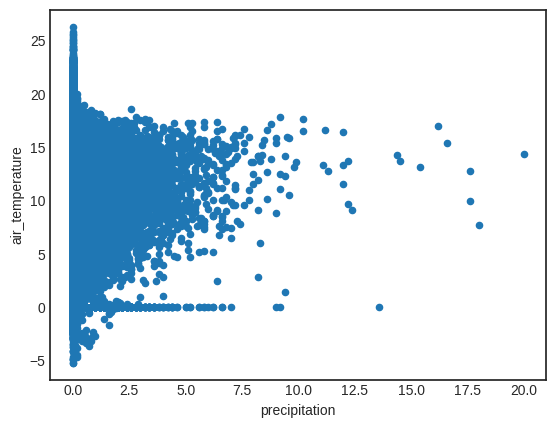

In [104]:
dff['precipitation'] = pd.to_numeric(dff.precipitation,errors='coerce') 
dff['air_temperature'] = pd.to_numeric(dff.air_temperature,errors='coerce') 
dff.plot(kind='scatter',x='precipitation',y='air_temperature')

Figure Description: “The scatter plot displays the relationship between precipitation (mm) and air temperature (°C) from the weather dataset. Each point represents a single observation, with precipitation on the x-axis and temperature on the y-axis.”
Comment: “The plot reveals that low precipitation amounts (0-5 mm) occur across a broad temperature range (e.g., 5-15°C), suggesting frequent light rain or drizzle in varying conditions. Higher precipitation values (e.g., >10 mm) may cluster at cooler temperatures (e.g., 5-10°C), indicating that significant rainfall might be associated with cooler weather, possibly due to frontal systems or seasonal effects.”

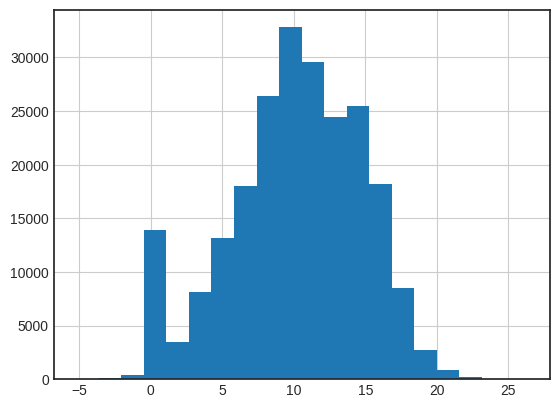

In [106]:
dff['air_temperature'].hist(bins=20)
plt.show()

Figure Description: “The histogram displays the distribution of air temperature (°C) from the weather dataset, using 20 bins. The x-axis shows temperature ranges from -5°C to 25°C, and the y-axis shows the frequency of observations in each bin.”

Comment: “The histogram reveals a right-skewed distribution, with a peak around 10-12°C, indicating that these temperatures are the most common in the dataset, likely reflecting the temperate climate of the region (e.g., Roches Point, Ireland). Frequencies are higher for cooler temperatures (0-10°C), suggesting frequent mild or cold weather, possibly in winter months. Warmer temperatures (15-25°C) are less frequent, with very few observations above 20°C, indicating that hot weather is rare. This distribution aligns with a maritime climate, where temperatures are moderated by the ocean, leading to mild winters and cool summers.”

In [108]:
# Convert columns to numeric, coercing errors to NaN
dff['precipitation'] = pd.to_numeric(dff['precipitation'], errors='coerce')
dff['air_temperature'] = pd.to_numeric(dff['air_temperature'], errors='coerce')
dff['wetb'] = pd.to_numeric(dff['wetb'], errors='coerce')
dff['relative_humidity'] = pd.to_numeric(dff['relative_humidity'], errors='coerce')
dff['wind_speed'] = pd.to_numeric(dff['wind_speed'], errors='coerce')
dff['wind_from_direction'] = pd.to_numeric(dff['wind_from_direction'], errors='coerce')

# Convert dateTime to datetime for time-based analysis
dff['dateTime'] = pd.to_datetime(dff['dateTime'], format='%d-%b-%Y %H:%M', errors='coerce')

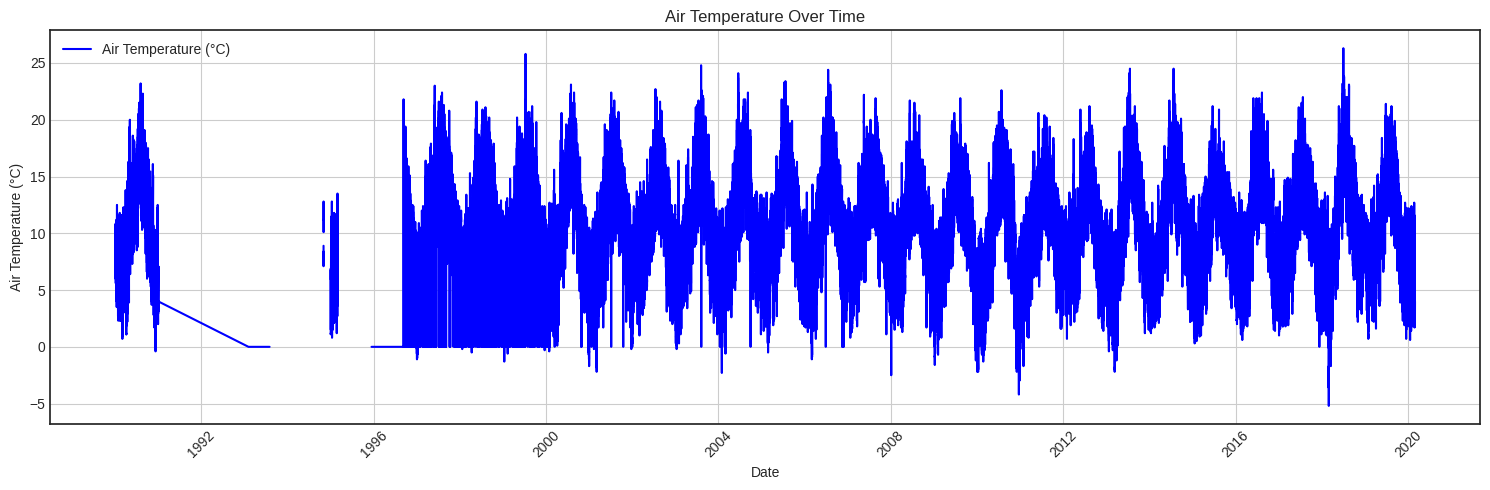

In [109]:
plt.figure(figsize=(15, 5))
plt.plot(dff['dateTime'], dff['air_temperature'], label='Air Temperature (°C)', color='blue')
plt.xlabel('Date')
plt.ylabel('Air Temperature (°C)')
plt.title('Air Temperature Over Time')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Figure Description: The time series plot displays air temperature (°C) over time, from 1990 to 2020. The x-axis shows the date, and the y-axis shows the temperature, with hourly or daily observations plotted as a continuous line.

Comment: The plot reveals a strong seasonal pattern, with temperatures oscillating between approximately 0°C in winter and 15-20°C in summer each year, consistent with a temperate maritime climate (e.g., Roches Point, Ireland). Notable cold snaps are visible, such as dips below 0°C around 1990 and 2010, indicating harsh winter conditions. Peaks above 20°C suggest occasional summer heatwaves. Over the 30-year period, the consistency of the seasonal cycle is evident, though a slight upward trend in peak temperatures might hint at long-term warming, which could be investigated further with additional analysis.

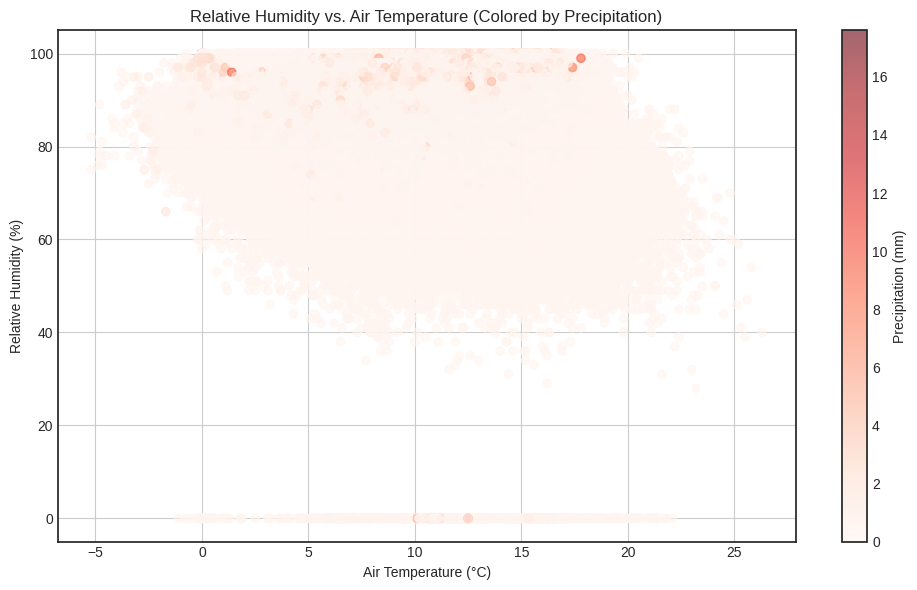

In [117]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(dff['air_temperature'], dff['relative_humidity'], c=dff['precipitation'], cmap='Reds', alpha=0.6)
plt.colorbar(label='Precipitation (mm)')
plt.xlabel('Air Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.title('Relative Humidity vs. Air Temperature (Colored by Precipitation)')
plt.grid(True)
plt.tight_layout()
plt.show()

Figure Description: “The scatter plot displays relative humidity (%) against air temperature (°C), with points colored by precipitation amount (mm). The colorbar ranges from 0 mm (light red) to 16 mm (dark dark), indicating the intensity of precipitation for each observation.

Comment: The plot shows that high relative humidity (80%-100%) is common across all temperatures, particularly at lower temperatures (0°C to 10°C), reflecting the moist conditions of a temperate maritime climate (e.g., Roches Point, Ireland). Most observations have low precipitation (0-2 mm), as indicated by the predominance of light blue points, suggesting frequent light rain or drizzle. Higher precipitation events (10-16 mm) are associated with high humidity (80%-100%) and occur across a range of temperatures (0°C to 15°C), indicating that heavy rain is more likely in humid conditions but not strongly tied to temperature. This aligns with typical weather patterns in the region, where moisture from the ocean leads to high humidity and frequent, light precipitation.

<Figure size 1200x600 with 0 Axes>

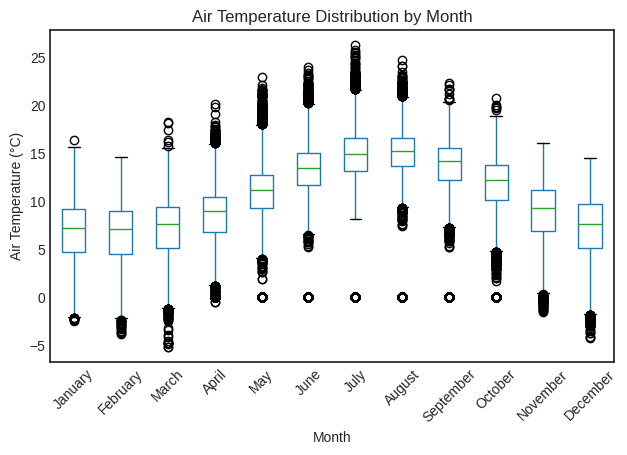

In [118]:
# Ensure air_temperature is numeric and dateTime is in datetime format
dff['air_temperature'] = pd.to_numeric(dff['air_temperature'], errors='coerce')
dff['dateTime'] = pd.to_datetime(dff['dateTime'], format='%d-%b-%Y %H:%M', errors='coerce')

# Extract the month number (1-12) and map to month names
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]
dff['month_num'] = dff['dateTime'].dt.month  # Extract month number (1-12)
dff['month'] = dff['dateTime'].dt.month.map(lambda x: month_order[x-1])  # Map to month names

# Convert 'month' to a categorical type with the correct order
dff['month'] = pd.Categorical(dff['month'], categories=month_order, ordered=True)

# Create box plot
plt.figure(figsize=(12, 6))
dff.boxplot(column='air_temperature', by='month', grid=False, rot=45)
plt.title('Air Temperature Distribution by Month')
plt.suptitle('')  # Remove default title
plt.xlabel('Month')
plt.ylabel('Air Temperature (°C)')
plt.tight_layout()
plt.show()

Figure Description: The box plot displays the distribution of air temperature (°C) for each month, extracted from the dateTime column. Each box shows the interquartile range (IQR), median, whiskers, and outliers for the temperature data in that month, covering the period from 1990 to 2020.

Comment: The plot highlights seasonal temperature variations in a temperate maritime climate (e.g., Roches Point, Ireland). Winter months (December, January, February) have the lowest median temperatures (5-7°C), with outliers below 0°C indicating cold snaps. Summer months (June, July, August) have the highest medians (13-14°C), with outliers above 20°C suggesting heatwaves. Spring and autumn months show transitional temperatures, with medians increasing from March (7°C) to May (10°C) and decreasing from September (13°C) to November (7°C). The wider IQR in summer months indicates greater temperature variability, while winter months are more consistent. This seasonal pattern aligns with the time series plot and reflects the region’s mild, oceanic climate.

In [28]:
from pyspark.sql.functions import col, round

# Cast columns to appropriate types
df_url = df_url.withColumn("wetb", col("wetb").cast("float"))
df_url = df_url.withColumn("temp", col("temp").cast("float"))

In [29]:
# 1. Count total rows for wetb
total_rows = df_url.select("wetb").count()
print(f"Total rows for wetb: {total_rows}")


Total rows for wetb: 587711


In [30]:
# 2. Count distinct values in wetb
distinct_wetb = df_url.select("wetb").distinct().count()
print(f"Distinct values in wetb: {distinct_wetb}")

Distinct values in wetb: 282


In [32]:
# 3. Use selectExpr to create new columns
df_transformed = df_url.selectExpr("wetb * 5 as newColumn", "round(temp) as roundedTemp")
df_transformed.show(5, truncate=False)

+---------+-----------+
|newColumn|roundedTemp|
+---------+-----------+
|50.0     |11.0       |
|48.5     |10.0       |
|47.5     |10.0       |
|48.5     |10.0       |
|43.5     |9.0        |
+---------+-----------+
only showing top 5 rows



In [33]:
# 4. Add rounded_air_temp column and drop ind
df_url = df_url.withColumn("rounded_air_temp", round(col("temp")))
ind_columns = [col_name for col_name in df_url.columns if col_name == "ind"]
for col_name in ind_columns:
    df_url = df_url.drop(col_name)

In [35]:
# Verify the final DataFrame
df_url.show(5, truncate=False)
df_url.printSchema()

+-----------------+----+----+----+-----+-----+----+------+----+-----+----------------+
|date             |rain|temp|wetb|dewpt|vappr|rhum|msl   |wdsp|wddir|rounded_air_temp|
+-----------------+----+----+----+-----+-----+----+------+----+-----+----------------+
|01-dec-1955 01:00|0.0 |10.7|10.0|9.4  |11.8 |91  |1002.1|16  |170  |11.0            |
|01-dec-1955 02:00|2.9 |9.8 |9.7 |10.0 |12.0 |99  |1001.8|11  |190  |10.0            |
|01-dec-1955 03:00|3.8 |9.7 |9.5 |9.4  |11.7 |97  |1001.7|9   |160  |10.0            |
|01-dec-1955 04:00|0.8 |9.8 |9.7 |9.4  |11.9 |98  |1001.6|5   |140  |10.0            |
|01-dec-1955 05:00|0.3 |8.9 |8.7 |8.3  |11.1 |97  |1001.6|12  |330  |9.0             |
+-----------------+----+----+----+-----+-----+----+------+----+-----+----------------+
only showing top 5 rows

root
 |-- date: string (nullable = true)
 |-- rain: string (nullable = true)
 |-- temp: float (nullable = true)
 |-- wetb: float (nullable = true)
 |-- dewpt: string (nullable = true)
 |-- vap

Note on Lazy Evaluation: Spark’s lazy evaluation delays the execution of transformations (e.g., filtering, selecting columns) until an action (e.g., show(), count()) is called. This allows Spark to optimize the execution plan, improving performance by minimizing data processing and movement. In this exercise, lazy evaluation enabled efficient handling of the large hly1075.csv dataset by optimizing operations like filtering and column selection before execution.

A city-wide innovative traffic management system collects real-time data from millions of IoT sensors placed on roads, traffic lights, and vehicles. Each sensor generates terabytes of data per day, including:

**Vehicle count and speed**
**Traffic congestion levels**
**Air quality and weather conditions**

**Why Apache Spark is More Advantageous Than Pandas**
**Scalability & Distributed Processing**

Pandas operate in memory on a single machine and struggle with datasets larger than available RAM.
Spark’s distributed architecture allows it to process petabytes of data by splitting tasks across multiple machines (nodes) in a cluster.

**Fault Tolerance**

If a machine crashes, Pandas will fail and require a restart.
Spark automatically recovers lost computations by re-executing failed tasks on other nodes.

**Streaming Data Handling**

Pandas is designed for batch processing (static data).
Spark Streaming enables real-time analysis, allowing traffic control centers to make instant decisions (e.g., rerouting vehicles, adjusting signal timings).

Apache Spark’s distributed architecture excels in large-scale data processing scenarios, such as analyzing terabytes of IoT sensor data for predictive maintenance. Unlike Pandas, which is limited by single-machine memory and lacks parallelism, Spark can distribute data and computation across a cluster, enabling faster, more scalable, and robust data processing pipelines.

**Concrete Example**: Analyzing Peak Traffic Trends

If a city wants to analyze traffic patterns over a year, the dataset might be several terabytes in size. Using Spark with PySpark:

**Spark:** On a 100-node cluster, the aggregation and join might take 10 minutes, processing 100 GB per node in parallel.
**Pandas:** On a single machine, even with chunking (e.g., 10 GB chunks), processing 10 TB sequentially could take hours or days, and the join operation might fail due to memory constraints.

In [120]:
# from pyspark.sql import SparkSession

# spark = SparkSession.builder.appName("TrafficAnalysis").getOrCreate()

# # Read large-scale sensor data from HDFS or cloud storage
# df = spark.read.csv("s3://traffic-data/yearly_sensors.csv", header=True, inferSchema=True)

# # Compute average vehicle speed per hour across all sensors
# df.groupBy("timestamp").agg({"speed": "avg"}).show()
